In [34]:
import numpy as np
import pandas as pd
from importlib import reload
import NpAutograd as npa
from NpAutograd import sigmoid, relu, BCELoss, leaky_relu
from NeuralNetwork import NeuralNetwork
from Optimizers.SGD import SGD, Adam
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
X = np.linspace(-1, 1, 100).reshape(-1, 1)
Y = X**2 + X #Same toy problem as before but now with the power of universal function approximators

In [43]:
mnist_train = pd.read_csv("data/mnist_train.csv", header=None).to_numpy(dtype=np.float32)
train_labels, train_data = mnist_train[:,0], mnist_train[:,1:]

In [45]:
train_labels.shape

(60000,)

In [15]:
neural_net = NeuralNetwork(1, 1, activation=leaky_relu)
optim = SGD(neural_net.get_params(), lr=1e-4)

In [26]:
for i in range(10_000):
    #Hacking RMSE into the loss
    preds = neural_net(X)
    error = preds - Y
    loss = ((error**2.).mean())**0.5
    loss.backward()
    optim.update_params()
    if i % 100 == 0:
        print(f"epoch {i} loss: {loss.v}")

epoch 0 loss: 0.007900479123925457
epoch 100 loss: 0.007886140527944322
epoch 200 loss: 0.007871882102292596
epoch 300 loss: 0.0078577164584903
epoch 400 loss: 0.007843653290719576
epoch 500 loss: 0.007829662376045439
epoch 600 loss: 0.007815762043510406
epoch 700 loss: 0.00780195710529416
epoch 800 loss: 0.007788235263873751
epoch 900 loss: 0.0077746071408836825
epoch 1000 loss: 0.007761050910252782
epoch 1100 loss: 0.007747614303912673
epoch 1200 loss: 0.007734231225767126
epoch 1300 loss: 0.0077209311471081185
epoch 1400 loss: 0.0077077371121027985
epoch 1500 loss: 0.007694611286633055
epoch 1600 loss: 0.007681578337841298
epoch 1700 loss: 0.007668618057428914
epoch 1800 loss: 0.007655739479211583
epoch 1900 loss: 0.007642959130429611
epoch 2000 loss: 0.007630248997021303
epoch 2100 loss: 0.007617617676079341
epoch 2200 loss: 0.007605085264265976
epoch 2300 loss: 0.007592816846702756
epoch 2400 loss: 0.0075806318302049005
epoch 2500 loss: 0.0075685265447615405
epoch 2600 loss: 0.007

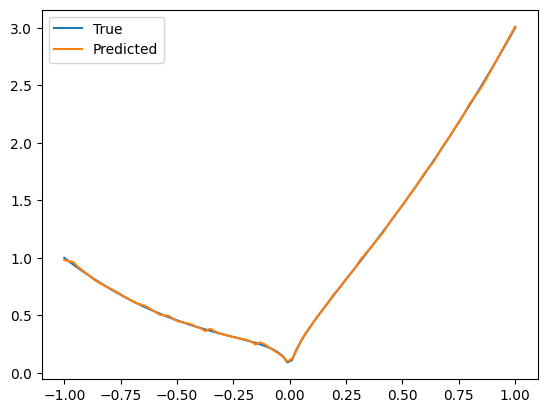

In [27]:
plt.plot(X, Y, label="True")
plt.plot(X, neural_net(X).v, label="Predicted")
plt.legend()
plt.show()

In [28]:
a = np.array([1., 2.])
b = npa.Tensor(np.array([3., 4.]))
2. ** b

(array([ 2., 10., 19., 44., 58., 45., 36., 22., 14.,  6.]),
 array([-2.60378772, -2.09016426, -1.5765408 , -1.06291734, -0.54929388,
        -0.03567041,  0.47795305,  0.99157651,  1.50519997,  2.01882343,
         2.53244689]),
 <BarContainer object of 10 artists>)

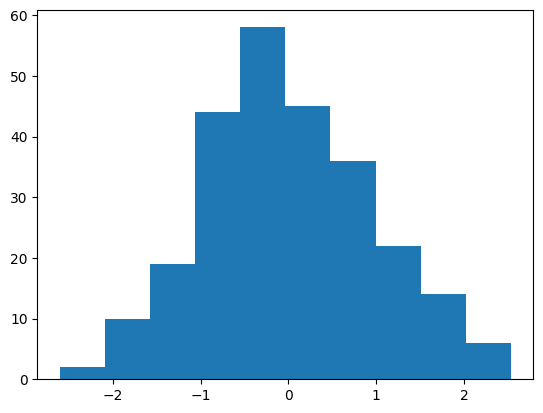

In [30]:
plt.hist(neural_net.layers[0].weights.v.flatten(), bins=10)

In [8]:
optim.params

In [9]:
neural_net.layers[0].get_params()

[<NpAutograd.Tensor at 0x111b34fb0>, <NpAutograd.Tensor at 0x111b06600>]

In [10]:
a = [1,2]
b =[]
b.extend(a)
b

[1, 2]